**O3 模型・重點小結**

1. **核心問題**

   * 你要分析一批文本，想先用 **GAP**（Generalized Association Plots）做可視化分群，再用 **LDA**（Latent Dirichlet Allocation）或其監督式變體（如 Labeled LDA）來取得每篇文本的主題分佈，判斷「偏向哪個主題」。

2. **兩種流程比較**

   | 流程 | 先做 GAP → 再做 LDA         | 先指定 topic→token → GAP 分群 → LDA 驗證 |
   | -- | ----------------------- | --------------------------------- |
   | 用途 | 讓可視化主動揭示隱含群，再以 LDA 量化主題 | 用專家/先驗定義 token 群，再檢驗實際分布          |
   | 優點 | 完全資料驅動，能發現意外結構          | 可驗證人為標籤、易對照 domain 知識             |
   | 風險 | GAP 聚類不一定對應可解釋主題        | 預先 token list 可能偏誤，限制 LDA 彈性      |

3. **主題歸屬 → 延伸應用**

   * **推薦系統**：把「文件–主題分布」對應成「使用者/商品–潛在偏好」，即可做內容推薦或商品推薦。
   * **顧客分析**：將每位顧客的行為紀錄視為文件，LDA 得到「顧客–主題偏好向量」，GAP 幫你做群組視覺化，便於客群分層、行銷定位。

4. **實作建議**

   1. **訓練**：對已標或未標文本跑 LDA（或 Labeled LDA 如果有多重標籤）。
   2. **推論**：輸入新文本，推斷其 `θ`（topic mixture），即得到「偏向哪個主題」的機率。
   3. **可視化／分群**：用 GAP 依 `θ` 或相似度排序，觀察群落與主題塊狀。
   4. **應用**：

      * 推薦：以使用者對主題的偏好去匹配文件或商品。
      * 分群：以顧客在主題空間的位置做 segmentation。

5. **下一步**

   * 若想快速驗證，可先用現成 LDA 套件（Gensim／sklearn）＋ R 版 GAP。
   * 需要設計推薦或顧客分析流程，再進一步整合「主題 → 相似度 → 排薦」的演算法。


### 有還原字型

In [20]:
import pandas as pd
import re, string
import numpy as np
np.random.seed(42)

In [ ]:


# import spacy
# nlp = spacy.load("en_core_web_sm")
# stopwords = nlp.Defaults.stop_words

# data = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\BERTopic\bbc-news-data.csv', sep='\t')

# def preprocess(text):
#     text = text.lower()  # 轉成小寫
#     text = re.sub(r'\d+', '', text)  # 移除數字
#     text = re.sub(r'[^\w\s]', '', text)  # 移除標點符號
#     text = re.sub(r'\s+', ' ', text).strip()  # 移除多餘空白
    
#     doc = nlp(text)
#     lemmatized_tokens = [token.lemma_ for token in doc if token.is_alpha and token.lemma_ not in stopwords and len(token.lemma_) > 1]
#     return lemmatized_tokens

# data['Tokens'] = data['content'].apply(preprocess)
# data['cleaned_content'] = data['Tokens'].apply(lambda x: ' '.join(x))
# data.to_csv('BBCnews_cleaned.csv', encoding='utf-8-sig')

### 沒有還原字型

In [ ]:
# import pandas as pd
# import re, string
# import numpy as np
# np.random.seed(42)
# # 下載並設定停用詞
# import nltk
# from nltk.corpus import stopwords
# nltk.download('stopwords')
# stop_words = stopwords.words('english')
# custom_stop = {'said', 'mr', 'also', 'would', 'new', 'one', 'like', 'could', 'us', 'many', 'get', 'use', 'two', 'first',
#                'told', 'say', 'may', 'good', 'last', 'make', 'well', 'next'}
# all_stopwords = set(stop_words).union(custom_stop)

# data = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\BERTopic\bbc-news-data.csv', sep='\t')

# def preprocess(text):
#     text = text.lower()  # 轉成小寫
#     text = re.sub(r'\d+', '', text)  # 移除數字
#     text = re.sub(r'[^\w\s]', '', text)  # 移除標點符號
#     text = re.sub(r'\s+', ' ', text).strip()  # 移除多餘空白
#     text = ' '.join([word for word in text.split() if word not in all_stopwords])  # 移除停用詞
#     return text

# data['cleaned_content'] = data['content'].apply(preprocess)
# data['Tokens'] = data['cleaned_content'].apply(lambda x: x.split())

---

---

In [21]:
import pandas as pd
data = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\BERTopic\BBCnews_cleaned.csv')
# 你把 list 存成 .csv 之後，pandas.read_csv 會把它當成 字串，不會還原回原本的 list。
# 所以
import ast
data['Tokens'] = data['Tokens'].apply(ast.literal_eval)


In [22]:
data['category'].value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

---

---

### 算文章的tfidf來設定seed

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

for label in data['category'].unique():
    docs = data[data['category'] == label]['cleaned_content']
    vec = TfidfVectorizer(max_df=0.8, min_df=5, stop_words='english')
    tfidf = vec.fit_transform(docs)
    top_words = sorted(zip(vec.get_feature_names_out(), 
                           tfidf.sum(axis=0).A1),
                           key=lambda x: -x[1])[:30]
    print(f'\'{label}\': {[w for w, _ in top_words]}' +',')

'business': ['bn', 'year', 'company', 'mr', 'firm', 'sale', 'rise', 'bank', 'market', 'share', 'price', 'growth', 'economy', 'rate', 'government', 'new', 'fall', 'oil', 'economic', 'profit', 'report', 'month', 'analyst', 'business', 'high', 'expect', 'dollar', 'figure', 'deal', 'world'],
'entertainment': ['film', 'good', 'award', 'year', 'star', 'music', 'win', 'band', 'include', 'number', 'new', 'album', 'festival', 'actor', 'play', 'mr', 'oscar', 'director', 'chart', 'tv', 'uk', 'bbc', 'record', 'song', 'million', 'time', 'release', 'british', 'people', 'singer'],
'politics': ['mr', 'labour', 'election', 'party', 'blair', 'government', 'tory', 'people', 'minister', 'lord', 'brown', 'plan', 'howard', 'tax', 'new', 'tell', 'year', 'chancellor', 'prime', 'public', 'britain', 'uk', 'home', 'mp', 'campaign', 'country', 'issue', 'vote', 'leader', 'work'],
'sport': ['win', 'play', 'game', 'england', 'player', 'good', 'year', 'world', 'club', 'match', 'time', 'team', 'come', 'cup', 'champion

In [24]:
seed = {
'business': ['bn', 'year', 'company', 'mr', 'firm', 'sale', 'rise', 'bank', 'market', 'share', 'price', 'growth', 'economy', 'rate', 'government', 'new', 'fall', 'oil', 'economic', 'profit', 'report', 'month', 'analyst', 'business', 'high', 'expect', 'dollar', 'figure', 'deal', 'world'],
'entertainment': ['film', 'good', 'award', 'year', 'star', 'music', 'win', 'band', 'include', 'number', 'new', 'album', 'festival', 'actor', 'play', 'mr', 'oscar', 'director', 'chart', 'tv', 'uk', 'bbc', 'record', 'song', 'million', 'time', 'release', 'british', 'people', 'singer'],
'politics': ['mr', 'labour', 'election', 'party', 'blair', 'government', 'tory', 'people', 'minister', 'lord', 'brown', 'plan', 'howard', 'tax', 'new', 'tell', 'year', 'chancellor', 'prime', 'public', 'britain', 'uk', 'home', 'mp', 'campaign', 'country', 'issue', 'vote', 'leader', 'work'],
'sport': ['win', 'play', 'game', 'england', 'player', 'good', 'year', 'world', 'club', 'match', 'time', 'team', 'come', 'cup', 'champion', 'second', 'injury', 'think', 'wale', 'ireland', 'open', 'season', 'want', 'coach', 'final', 'chelsea', 'rugby', 'set', 'new', 'france'],
'tech': ['game', 'people', 'mobile', 'phone', 'use', 'technology', 'service', 'mr', 'user', 'music', 'software', 'new', 'computer', 'year', 'site', 'digital', 'firm', 'network', 'net', 'broadband', 'microsoft', 'player', 'search', 'million', 'email', 'online', 'company', 'tv', 'program', 'pc'],
}


In [25]:

selected_tokens = set()
for words in seed.values():
    selected_tokens.update(words)

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(vocabulary=list(selected_tokens))
X = vectorizer.fit_transform(data['cleaned_content'])

tf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tf_df.to_csv("還原字型0.8_5的tfidf前30.txt", index=False, sep='\t')


---

---

In [70]:
import numpy as np
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

# === Step 1: 產生每個 token 的語意向量（P × K） ===
# tf_df: N × P 的詞頻矩陣；lda_probs: N × K 的文件 topic 機率
tf_matrix = tf_df.T.values  # 變成 P × N # 轉置 tf_df 成 P × N，方便矩陣乘法
token_vectors = tf_matrix @ lda_probs  # P × K

token_sums = tf_matrix.sum(axis=1, keepdims=True)
token_sums[token_sums == 0] = 1e-10  # # 加上一個微小常數 epsilon 避免除以 0
token_vectors = token_vectors / token_sums  # 平均化
# 可選：L2 normalize 每個 token 向量
token_vectors = normalize(token_vectors, axis=1)

# === Step 2: 準備 GAP topic → LDA topic 的 mapping（topic 是 1~5） ===
gap_topics = sorted(token_df['topic'].unique())  
gap_to_lda = {gap_k: lda_k for lda_k, gap_k in enumerate(gap_topics)}  # ex: {1:0, 2:1, ..., 5:4}

# === Step 3: 建立 GAP 每一群的中心向量 ===
cluster_centers = []

for gap_k in gap_topics:
    cluster_token_idx = token_df[token_df['topic'] == gap_k].index
    cluster_vecs = token_vectors[cluster_token_idx]

    if len(cluster_vecs) == 0:
        center = np.random.rand(token_vectors.shape[1])  # 防止空群
    else:
        center = cluster_vecs.mean(axis=0)

    center = center / (np.linalg.norm(center) + 1e-10)   # normalize
    cluster_centers.append(center)

cluster_centers = np.vstack(cluster_centers)  # shape: K × K

# === Step 4: 每個 token 計算與 GAP 群的相似度，建 η 矩陣 ===
eta_matrix = []

for vec in token_vectors:  # 每個 token 的語意向量（已正規化）
    similarities = cosine_similarity([vec], cluster_centers)[0]  # shape: (K,)

    # 加平滑，避免 0；可加權強化差異（softmax with temperature）
    temp = 10  # 調整這個值可改變集中程度
    similarities = np.clip(similarities, 1e-6, 1.0)
    soft_weights = np.exp(temp * similarities)
    soft_weights /= soft_weights.sum()
    eta_matrix.append(soft_weights)

# === Step 5: 轉置成 gensim 所需格式（K × P） ===
eta_matrix = np.array(eta_matrix).T # shape: (K_topic, P_token)
print("eta_matrix shape:", eta_matrix.shape)


eta_matrix shape: (5, 123)


In [ ]:
from gensim.corpora import Dictionary
from gensim.models.ldamodel import LdaModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import pandas as pd
import numpy as np

# === 1. 建立字典與語料 ===
dictionary = Dictionary(data['Tokens'])
corpus = [dictionary.doc2bow(tokens) for tokens in data['Tokens']]

# === 2. 建立 TF 矩陣（P x N） ===
tf_df = pd.DataFrame(0, index=dictionary.token2id.keys(), columns=range(len(data)))
for doc_id, tokens in enumerate(data['Tokens']):
    for token in tokens:
        if token in tf_df.index:
            tf_df.loc[token, doc_id] += 1

tf_matrix = tf_df.values  # P × N
V = len(dictionary)

# === 3. 讀取 token 分群（GAP） ===
token_df = pd.read_csv('還原字型0.8_5的tfidf前30手動分群.csv')
token_df = token_df[token_df['token'].isin(dictionary.token2id)].reset_index(drop=True)

# 重新建立 token_index（對應 tf_df 的 index）
token_index_map = {token: idx for idx, token in enumerate(tf_df.index)}
token_df['token_idx'] = token_df['token'].map(token_index_map)

# === 4. 建立 token_vectors：每個 token 在 topic 空間的語意向量 ===
K = 5  # 預設 topic 數
lda_probs = np.random.dirichlet([1]*K, size=len(data))  # dummy LDA output if not from previous

token_vectors = tf_matrix @ lda_probs  # P × K
token_sums = tf_matrix.sum(axis=1, keepdims=True)
token_sums[token_sums == 0] = 1e-10
token_vectors = token_vectors / token_sums
token_vectors = normalize(token_vectors, axis=1)

# === 5. 建 GAP topic → LDA topic mapping ===
gap_topics = sorted(token_df['topic'].unique())
gap_to_lda = {gap_k: lda_k for lda_k, gap_k in enumerate(gap_topics)}

# === 6. GAP cluster centers ===
cluster_centers = []
for gap_k in gap_topics:
    cluster_token_idx = token_df[token_df['topic'] == gap_k]['token_idx']
    cluster_vecs = token_vectors[cluster_token_idx]

    if len(cluster_vecs) == 0:
        center = np.random.rand(K)
    else:
        center = cluster_vecs.mean(axis=0)

    center /= (np.linalg.norm(center) + 1e-10)
    cluster_centers.append(center)

cluster_centers = np.vstack(cluster_centers)

# === 7. 建立 η 矩陣（K × V） ===
eta_rows = []

for i in range(V):
    vec = token_vectors[i]
    similarities = cosine_similarity([vec], cluster_centers)[0]
    temp = 10
    similarities = np.clip(similarities, 1e-6, 1.0)
    soft_weights = np.exp(temp * similarities)
    soft_weights /= soft_weights.sum()
    eta_rows.append(soft_weights)

eta = np.array(eta_rows).T  # K × V

# === 8. 建立 LDA 模型 ===
lda = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=K,
    eta=eta,
    random_state=42,
    iterations=100,
    passes=10,
    alpha=0.1
)

# === 9. 顯示主題結果 ===
print("\n每個主題的前 20 詞：")
for k in range(K):
    top_words = lda.show_topic(k, topn=20)
    print(f"Topic {k+1}: {[w for w, _ in top_words]}")

# === 10. 顯示 η 中有套用 GAP 的 token 數量 ===
covered_words = [w for w in token_df['token'] if w in dictionary.token2id]
print(f"\n你的 GAP 分群中共 {len(token_df)} 個 token，其中 {len(covered_words)} 個成功對應到 dictionary。")



每個主題的前 20 詞：
Topic 1: ['game', 'use', 'people', 'computer', 'technology', 'user', 'pc', 'new', 'software', 'search', 'mr', 'time', 'year', 'play', 'firm', 'machine', 'find', 'work', 'system', 'microsoft']
Topic 2: ['film', 'year', 'good', 'sale', 'win', 'award', 'pp', 'play', 'star', 'include', 'number', 'new', 'music', 'uk', 'time', 'bn', 'director', 'band', 'release', 'title']
Topic 3: ['mr', 'year', 'government', 'new', 'world', 'people', 'tell', 'time', 'come', 'win', 'minister', 'plan', 'game', 'labour', 'think', 'election', 'party', 'good', 'bn', 'want']
Topic 4: ['mobile', 'people', 'phone', 'service', 'technology', 'use', 'digital', 'music', 'tv', 'new', 'consumer', 'year', 'broadband', 'player', 'video', 'device', 'mr', 'content', 'million', 'way']
Topic 5: ['site', 'attack', 'email', 'company', 'firm', 'people', 'use', 'software', 'net', 'spam', 'legal', 'security', 'system', 'website', 'user', 'mr', 'network', 'file', 'online', 'information']

你的 GAP 分群中共 123 個 token，其中 123

---

---

In [34]:
from gensim.corpora import Dictionary
from gensim.models.ldamodel import LdaModel
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, adjusted_rand_score, classification_report
import pandas as pd
import numpy as np

# 1. 建立詞典與語料

dictionary = Dictionary(data['Tokens'])
corpus = [dictionary.doc2bow(tokens) for tokens in data['Tokens']]

# 2. 讀取 token-to-topic mapping
token_df = pd.read_csv('還原字型0.8_5的tfidf前30手動分群.csv')
token_to_topic = dict(zip(token_df['token'], token_df['topic']))

# 3. 建立 η 矩陣
K = 5
eta_strength=0.3

V = len(dictionary.token2id)
eta = np.full((K, V), 0.01)
for word, topic_id in token_to_topic.items():
    if topic_id < K and word in dictionary.token2id:
        word_id = dictionary.token2id[word]
        eta[topic_id][word_id] = eta_strength

# 4. 建立 LDA 模型
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=K,
               eta=eta, random_state=42, iterations=100, passes=10, alpha=0.1)

# lda.save('20250719lda_model.model')
# dictionary.save('20250719dictionary.dict')

# 5. 主題詞顯示
print("\n每個主題的前 20 詞：")
for k in range(K):
    top_words = lda.show_topic(k, topn=20)
    print(f"Topic {k+1}: {[w for w, _ in top_words]}")

covered_words = [word for word in token_to_topic if word in dictionary.token2id]
print(f"你的 token_to_topic 裡共 {len(token_to_topic)} 個詞，其中 {len(covered_words)} 個有成功對應到 dictionary。")



每個主題的前 20 詞：
Topic 1: ['game', 'use', 'people', 'computer', 'technology', 'pc', 'user', 'search', 'software', 'new', 'mr', 'time', 'machine', 'microsoft', 'find', 'work', 'year', 'firm', 'play', 'release']
Topic 2: ['year', 'film', 'good', 'sale', 'win', 'award', 'pp', 'include', 'new', 'music', 'play', 'bn', 'star', 'number', 'rise', 'uk', 'price', 'title', 'release', 'time']
Topic 3: ['mr', 'year', 'government', 'world', 'people', 'time', 'tell', 'new', 'game', 'play', 'come', 'win', 'think', 'plan', 'minister', 'labour', 'work', 'need', 'party', 'election']
Topic 4: ['phone', 'mobile', 'people', 'service', 'technology', 'digital', 'music', 'use', 'tv', 'new', 'broadband', 'consumer', 'player', 'year', 'video', 'million', 'device', 'content', 'market', 'gadget']
Topic 5: ['firm', 'site', 'company', 'attack', 'system', 'email', 'use', 'people', 'security', 'net', 'software', 'legal', 'network', 'file', 'mr', 'website', 'spam', 'virus', 'user', 'law']
你的 token_to_topic 裡共 123 個詞，其中 12

---

### 儲存已經跑的工作區和模型

In [ ]:
# import joblib

# # 打包所有重要物件成一個 workspace dict
# workspace = {
#     'df': data,  # 你的 DataFrame
#     'tokens': data['Tokens'],  # 你的 Tokens
#     'dictionary': dictionary,  # gensim Dictionary
#     'corpus': corpus,  # gensim Corpus
#     'lda_model': lda # gensim LDA Model
# }

# # 儲存整個 workspace
# joblib.dump(workspace, '20250719_0.8_5_30.pkl')


['20250719_0.8_5_30.pkl']

---

### 讀取已經儲存的工作區

In [26]:
import joblib

# 讀取儲存的工作區物件
workspace = joblib.load('20250719_0.8_5_30.pkl')

# 從中提取你需要的物件
data = workspace['df']
tokens = workspace['tokens']
dictionary = workspace['dictionary']
corpus = workspace['corpus']
lda_model = workspace['lda_model']


### 讀取已經跑的模型

In [12]:
# from gensim.models import LdaModel
# from gensim.corpora import Dictionary

# lda = LdaModel.load('20250719lda_model.model')
# dictionary = Dictionary.load('20250719dictionary.dict')


---

In [75]:
import pandas as pd

doc_topics = lda.get_document_topics(corpus, minimum_probability=0)

topic_distributions = pd.DataFrame([
    [prob for _, prob in doc] for doc in doc_topics
])

K = 5
topic_distributions.columns = [f"Topic_{i+1}" for i in range(K)]
topic_distributions['BBC_Label'] = data['category'].values

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(topic_distributions.iloc[:, :K].values)

topic_distributions['x'] = X_embedded[:, 0]
topic_distributions['y'] = X_embedded[:, 1]

# plt.figure(figsize=(8,6))
# sns.scatterplot(data=topic_distributions, x='x', y='y', hue='BBC_Label', palette='tab10')
# plt.title('LDA Topic Distribution (t-SNE Projection) by BBC Category')
# plt.show()


In [76]:
# 拿每篇文件的 topic 分布（含所有 topic，minimum_probability=0 確保每個都有出現）
doc_topics = lda.get_document_topics(corpus, minimum_probability=0)

topic_distributions = pd.DataFrame([[prob for _, prob in doc] for doc in doc_topics])
topic_distributions.columns = [f"Topic_{i+1}" for i in range(K)]  # 從 1 開始好看一點
topic_distributions['BBC_Label'] = data['category'].values  # 加上原 BBC 分類方便比對

print(topic_distributions.head())


    Topic_1   Topic_2   Topic_3   Topic_4   Topic_5 BBC_Label
0  0.000479  0.437643  0.165389  0.300485  0.096004  business
1  0.000527  0.000527  0.935328  0.033411  0.030208  business
2  0.000729  0.000729  0.836714  0.000729  0.161099  business
3  0.000499  0.110235  0.577382  0.000499  0.311384  business
4  0.000711  0.598535  0.399333  0.000711  0.000711  business


In [77]:
mean_distribution_per_label = topic_distributions.groupby('BBC_Label').mean()
print(mean_distribution_per_label.T) 

BBC_Label  business  entertainment  politics     sport      tech
Topic_1    0.025311       0.014280  0.006097  0.003155  0.355996
Topic_2    0.114229       0.697445  0.007414  0.170698  0.038425
Topic_3    0.735280       0.222048  0.940814  0.816598  0.077981
Topic_4    0.040449       0.043527  0.009044  0.002085  0.339958
Topic_5    0.084731       0.022700  0.036632  0.007464  0.187641


In [78]:
topic_distributions

,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,BBC_Label
0,0.000479,0.437643,0.165389,0.300485,0.096004,business
1,0.000527,0.000527,0.935328,0.033411,0.030208,business
2,0.000729,0.000729,0.836714,0.000729,0.161099,business
3,0.000499,0.110235,0.577382,0.000499,0.311384,business
4,0.000711,0.598535,0.399333,0.000711,0.000711,business
...,...,...,...,...,...,...
2220,0.000464,0.000464,0.000464,0.673218,0.325388,tech
2221,0.000545,0.000545,0.000545,0.000545,0.997819,tech
2222,0.042108,0.000216,0.000216,0.081971,0.875489,tech
2223,0.000537,0.000537,0.000537,0.360325,0.638065,tech


In [79]:
from scipy.spatial.distance import cdist
from sklearn.metrics import accuracy_score, classification_report, adjusted_rand_score

# 1️⃣ 準備 one-hot topic vectors
one_hot_topics = np.eye(K)  # 產生 K x K 單位矩陣，每一列就是一個 one-hot vector

# 2️⃣ 將原 dataframe 的 LDA topic 機率轉為 numpy array
lda_probs = topic_distributions.iloc[:, :K].values  # 取前 K 欄 (Topic_1, Topic_2...)

# 3️⃣ 計算每個文件對每個 one-hot 的距離
distances = cdist(lda_probs, one_hot_topics, metric='euclidean')  # (N x K)

# 4️⃣ 找出最小距離的 one-hot index，視為該文件屬於該 topic
pred_topic_by_distance = np.argmin(distances, axis=1)+1 # 1-based topic index

# 5️⃣ BBC label 轉成數值 (0 ~ 4)，方便比較
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
true_label = le.fit_transform(data['category'])

# # 6️⃣ 評估效果
# acc = accuracy_score(true_label, pred_topic_by_distance)
# ari = adjusted_rand_score(true_label, pred_topic_by_distance)
# report = classification_report(true_label, pred_topic_by_distance, target_names=le.classes_)

# print("\nAccuracy:", round(acc, 4))
# print("Adjusted Rand Index (ARI):", round(ari, 4))
# print("\nClassification Report:\n", report)


In [80]:
pred_topic_by_distance

array([2, 3, 3, ..., 5, 5, 1], dtype=int64)

In [81]:
import numpy as np
import pandas as pd

mapped_df = pd.DataFrame({
    'true_label': data['category'].values,
    'pred_topic': pred_topic_by_distance
})

print(mapped_df.groupby(['true_label', 'pred_topic']).size())


true_label     pred_topic
business       1               6
               2              44
               3             440
               4               7
               5              13
entertainment  1               1
               2             297
               3              84
               4               3
               5               1
politics       3             417
sport          2              85
               3             426
tech           1             159
               2               7
               3              23
               4             132
               5              80
dtype: int64


In [82]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist

# 你的 LDA topic 分布（N x K matrix）
lda_probs = topic_distributions.iloc[:, :K].values

# ground truth label to one-hot (vec-y)
N = len(true_label)
K = len(le.classes_)

Y_onehot = np.zeros((N, K))
Y_onehot[np.arange(N), true_label] = 1

from sklearn.metrics.pairwise import cosine_similarity

consistency_scores = []

for y_true, y_hat in zip(Y_onehot, lda_probs):
    score = cosine_similarity([y_true], [y_hat])[0][0]
    consistency_scores.append(score)

print("Average Consistency (y vs y_hat):", round(np.mean(consistency_scores), 4))

category_centroids = {}

for idx, label in enumerate(le.classes_):
    mask = (true_label == idx)
    centroid = lda_probs[mask].mean(axis=0)
    category_centroids[label] = centroid

centroid_matrix = np.vstack(list(category_centroids.values()))

# 類別中心兩兩 cosine 相似度
similarity_matrix = cosine_similarity(centroid_matrix)

# 類別中心兩兩 L2 距離
distance_matrix = cdist(centroid_matrix, centroid_matrix, metric='euclidean')

centroid_df = pd.DataFrame(similarity_matrix, index=le.classes_, columns=le.classes_)
print("\nCategory Center Cosine Similarity:")
print(centroid_df)

distance_df = pd.DataFrame(distance_matrix, index=le.classes_, columns=le.classes_)
print("\nCategory Center L2 Distance:")
print(distance_df)


Average Consistency (y vs y_hat): 0.3798

Category Center Cosine Similarity:
               business  entertainment  politics     sport      tech
business       1.000000       0.448563  0.985304  0.991454  0.250549
entertainment  0.448563       1.000000  0.311757  0.491200  0.174232
politics       0.985304       0.311757  1.000000  0.979964  0.170599
sport          0.991454       0.491200  0.979964  1.000000  0.164937
tech           0.250549       0.174232  0.170599  0.164937  1.000000

Category Center L2 Distance:
               business  entertainment  politics     sport      tech
business       0.000000       0.779440  0.239421  0.133170  0.804635
entertainment  0.779440       0.000000  0.997104  0.795629  0.828799
politics       0.239421       0.997104  0.000000  0.207362  1.000090
sport          0.133170       0.795629  0.207362  0.000000  0.913329
tech           0.804635       0.828799  1.000090  0.913329  0.000000


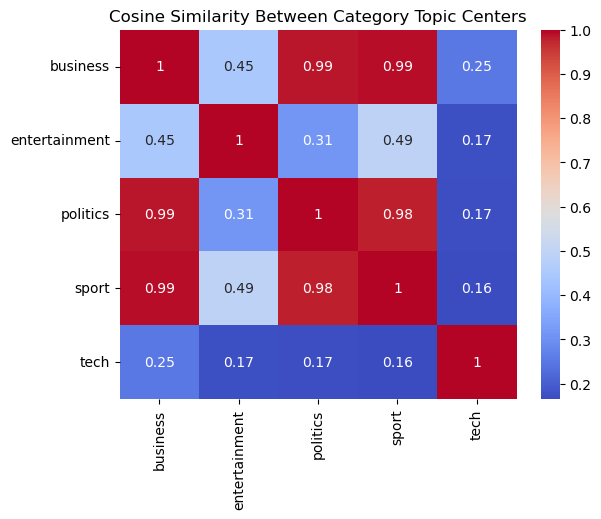

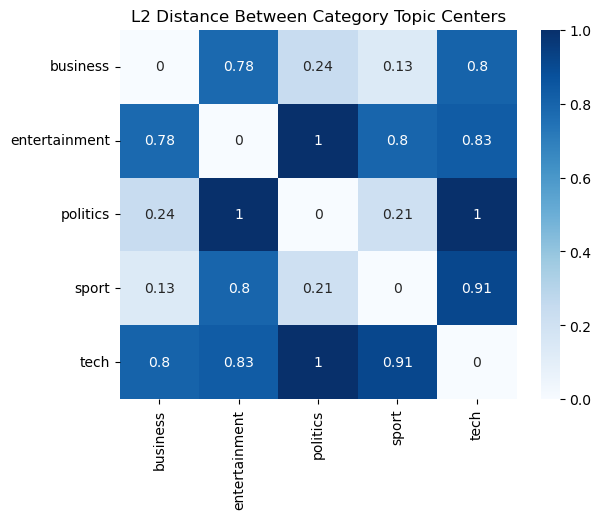

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(centroid_df, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Between Category Topic Centers")
plt.show()

sns.heatmap(distance_df, annot=True, cmap='Blues')
plt.title("L2 Distance Between Category Topic Centers")
plt.show()


---

---

### 原版LDA, 甚麼都不加, 只有token的訊息和基本參數設定

In [57]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

data = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\BERTopic\BBCnews_cleaned.csv')
texts = data['Tokens'].apply(eval).tolist()

dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

vectorizer = CountVectorizer(analyzer=lambda x: x)
doc_term_matrix = vectorizer.fit_transform(texts)

lda_gensim = LdaModel(corpus=corpus, num_topics=5, id2word=dictionary, random_state=0)

coherence_model = CoherenceModel(model=lda_gensim, texts=texts, dictionary=dictionary, coherence='c_v')
print('gensim coherence:', coherence_model.get_coherence())

# 取得 gensim LDA 每篇文章對 topic 的機率分佈
doc_topic_gensim = np.array([
    [prob for _, prob in lda_gensim.get_document_topics(doc, minimum_probability=0)] 
    for doc in corpus
])

# 準備 one-hot 真實分類
N = len(true_label)
K = lda_gensim.num_topics  # 確保 K 取自 gensim
Y_onehot = np.zeros((N, K))
Y_onehot[np.arange(N), true_label] = 1

# 計算 consistency
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist

lda_probs = doc_topic_gensim
consistency_scores = [cosine_similarity([y_true], [y_hat])[0][0] for y_true, y_hat in zip(Y_onehot, lda_probs)]
print("\nGensim - Average Consistency:", round(np.mean(consistency_scores), 4))

# 每個類別計算 topic 機率的 centroid
category_centroids = {}
for idx, label in enumerate(le.classes_):
    mask = (true_label == idx)
    centroid = lda_probs[mask].mean(axis=0)
    category_centroids[label] = centroid

# 計算 Cosine 與 L2 距離
centroid_matrix = np.vstack(list(category_centroids.values()))
similarity_matrix = cosine_similarity(centroid_matrix)
distance_matrix = cdist(centroid_matrix, centroid_matrix, metric='euclidean')

print("\nGensim - Cosine Similarity:")
print(pd.DataFrame(similarity_matrix, index=le.classes_, columns=le.classes_))
print("\nGensim - L2 Distance:")
print(pd.DataFrame(distance_matrix, index=le.classes_, columns=le.classes_))


gensim coherence: 0.4696289176677143

Gensim - Average Consistency: 0.3434

Gensim - Cosine Similarity:
               business  entertainment  politics     sport      tech
business       1.000000       0.899586  0.990450  0.885319  0.558143
entertainment  0.899586       1.000000  0.892656  0.997767  0.389693
politics       0.990450       0.892656  1.000000  0.878639  0.566446
sport          0.885319       0.997767  0.878639  1.000000  0.334776
tech           0.558143       0.389693  0.566446  0.334776  1.000000

Gensim - L2 Distance:
               business  entertainment  politics     sport      tech
business       0.000000       0.315853  0.081946  0.371385  0.510954
entertainment  0.315853       0.000000  0.326644  0.077561  0.684668
politics       0.081946       0.326644  0.000000  0.382129  0.499582
sport          0.371385       0.077561  0.382129  0.000000  0.758593
tech           0.510954       0.684668  0.499582  0.758593  0.000000
